In [2]:
import pandas as pd
import numpy as np

# run this command in terminal first: pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# run this command in terminal first: pip install pandas scikit-learn xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.cluster import KMeans

# run this command in terminal first: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# from P'Pun's code 
# run this command in terminal first: pip install umap-learn
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from umap import UMAP
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score


C:\Users\Norawit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('cleaned_yrbs_data.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15694 entries, 0 to 15693
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         15694 non-null  float64
 1   gender                      15694 non-null  str    
 2   education_level             15694 non-null  str    
 3   ride_drinking_driver        15694 non-null  float64
 4   school_safety_concern       15694 non-null  float64
 5   threatened_at_school        15694 non-null  float64
 6   fight_count                 15694 non-null  float64
 7   school_fight_count          15694 non-null  float64
 8   neighborhood_violence       15694 non-null  float64
 9   sexual_violence             15694 non-null  float64
 10  school_racism               15694 non-null  float64
 11  school_bullying             15694 non-null  float64
 12  cyber_bullying              15694 non-null  float64
 13  feel_hopeless               15694 non-null

C:\Users\Norawit\AppData\Local\Temp\ipykernel_27108\3488811937.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


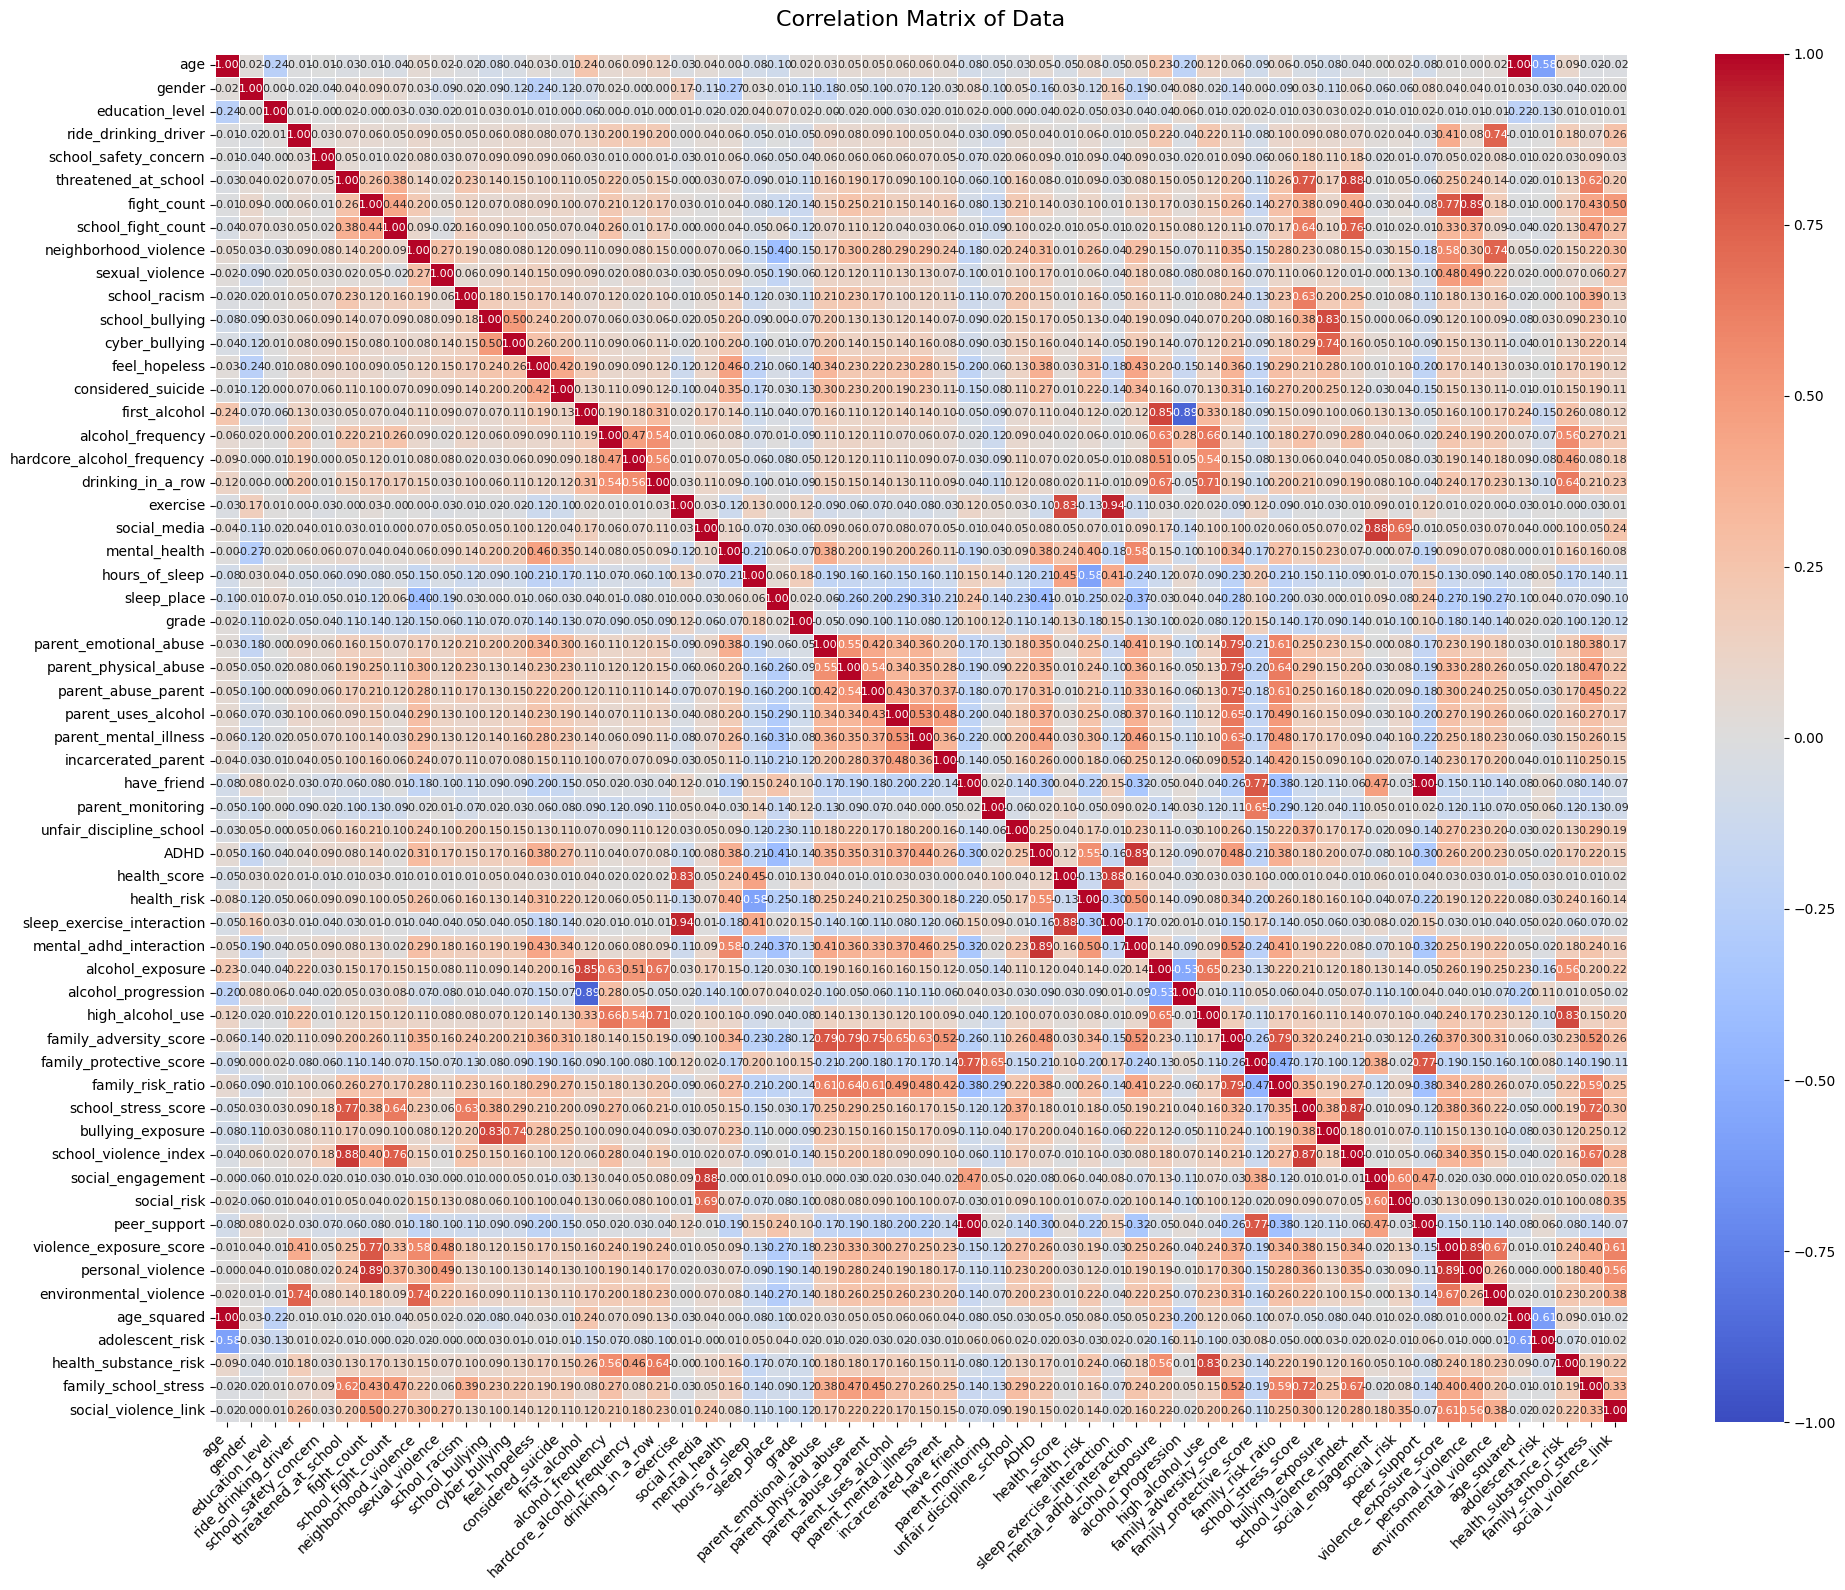

In [32]:
from sklearn.preprocessing import LabelEncoder


df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(20, 16))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f",
            annot_kws={"size": 8},
            linewidths=0.5,
            vmin=-1, vmax=1
            )   

plt.title('Correlation Matrix of Data', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
le = LabelEncoder()
df['grade_encoded'] = le.fit_transform(df['grade'])

X = df.drop(columns=['grade', 'grade_encoded'])
y = df['grade_encoded']

#  Column ที่เป็น String 
cat_features = ['gender', 'education_level', 'considered_suicide', 'sleep_place']

# แปลงประเภทข้อมูลให้เป็น category
for col in cat_features:
    X[col] = X[col].astype('category')

# แบ่งข้อมูลเป็น Train/Test -> 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    enable_categorical=True,  # เอาไว้ให้ใช้ category ที่แปลงมา
    tree_method='hist',
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))

Accuracy: 0.4438
              precision    recall  f1-score   support

         0.0       0.32      0.12      0.18        90
         1.0       0.09      0.02      0.03       154
         2.0       0.35      0.15      0.21       565
         3.0       0.38      0.32      0.35      1052
         4.0       0.49      0.75      0.60      1278

    accuracy                           0.44      3139
   macro avg       0.33      0.27      0.27      3139
weighted avg       0.40      0.44      0.40      3139



C:\Users\Norawit\AppData\Local\Temp\ipykernel_27108\4047624257.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


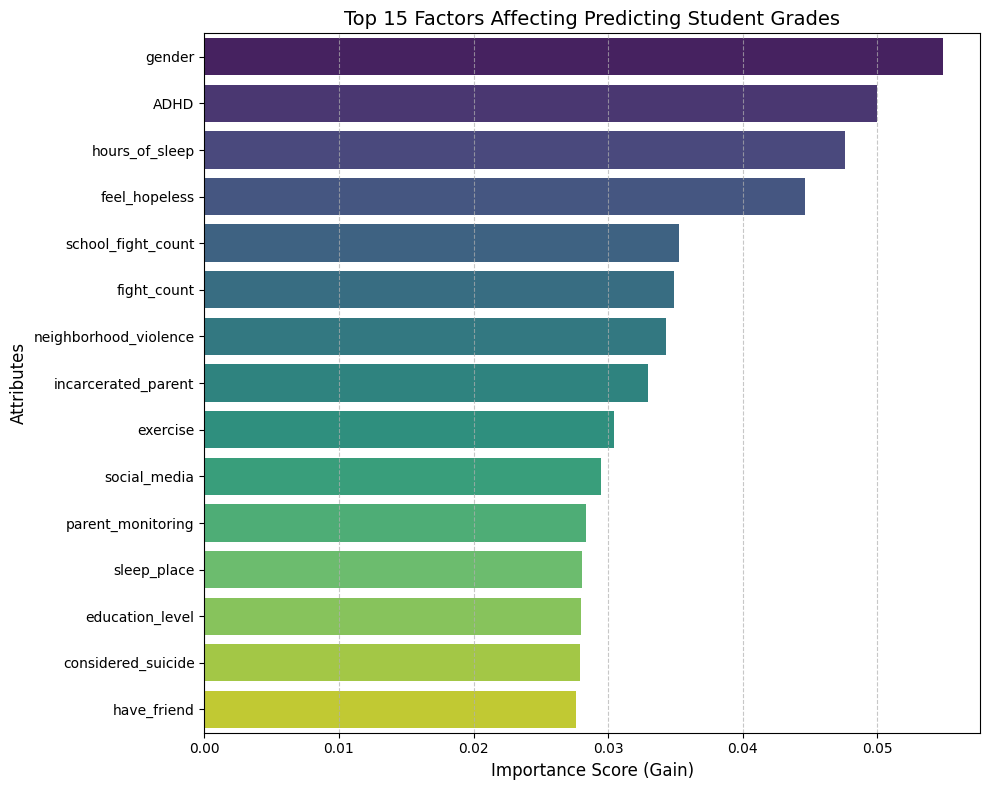

In [7]:
# ดึงค่าความสำคัญของ Feature ออกมา
importances = model.feature_importances_
feature_names = X.columns

# สร้าง DataFrame แล้วเอาไป plot
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# วาดกราฟ 
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(15),
    palette='viridis'
)

plt.title('Top 15 Factors Affecting Predicting Student Grades', fontsize=14)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Attributes', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
# ยุบกลุ่มเกรดเป็น 3 กลุ่ม (Low, Mid, High) เพื่อดูภาพรวม

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

# ยุบเกรดเป็น 3 กลุ่ม (Low, Mid, High)
# สร้าง Dictionary ใช้ Mapping
# 0,1 -> 0 (Low) | 2 -> 1 (Mid) | 3,4 -> 2 (High)
grade_group_map = {0: 0, 1: 0, 2: 1, 3: 2, 4: 2}
y_grouped = df['grade'].astype(int).map(grade_group_map)

# Feature Engineering
# Sleep x ADHD: ดูว่าการพักผ่อนน้อยส่งผลกับเด็ก ADHD แค่ไหน
df['sleep_adhd_interaction'] = df['hours_of_sleep'] * df['ADHD']

X = df.drop(columns=['grade', 'gender', 'education_level', 'sleep_place', 'grade_encoded'], errors='ignore')

# จัดการ String ใน X ให้เป็นตัวเลขทั้งหมด
for col in X.select_dtypes(include=['object', 'string']).columns:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y_grouped, test_size=0.2, random_state=42, stratify=y_grouped
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

#  Hyperparameters Tuning
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=3,           # ลดความลึกเพื่อป้องกันการจำ Noise
    min_child_weight=5,    # บังคับให้แต่ละโหนดต้องมีข้อมูลจำนวนหนึ่ง
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    objective='multi:softprob'
)

model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)
print(f"--- ผลลัพธ์หลังยุบกลุ่มเกรด (3 กลุ่ม) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

# Cross Validation
cv_scores = cross_val_score(model, X, y_grouped, cv=5)
print(f"CV Accuracy เฉลี่ย: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

target_names = ['Low (GPA 0-1)', 'Mid (GPA 2)', 'High (GPA 3-4)']
print(classification_report(y_test, y_pred, target_names=target_names))

--- ผลลัพธ์หลังยุบกลุ่มเกรด (3 กลุ่ม) ---
Accuracy Score: 0.7212
CV Accuracy เฉลี่ย: 0.7447 (+/- 0.0006)
                precision    recall  f1-score   support

 Low (GPA 0-1)       0.25      0.23      0.24       270
   Mid (GPA 2)       0.26      0.02      0.04       533
High (GPA 3-4)       0.77      0.94      0.85      2336

      accuracy                           0.72      3139
     macro avg       0.43      0.40      0.38      3139
  weighted avg       0.64      0.72      0.66      3139



In [9]:
# เตรียมข้อมูล
y = df['grade'].astype(int)

# Feature Engineering 
df['sleep_adhd_interaction'] = df['hours_of_sleep'] * df['ADHD']

X = df.drop(columns=['grade', 'gender', 'education_level', 'sleep_place', 'grade_encoded'], errors='ignore')

# จัดการ Missing values และ Numeric conversion
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

# แบ่งข้อมูลและปรับสมดุล (SMOTE)
# เนื่องจากมี 5 กลุ่ม การทำ SMOTE จะช่วยป้องกันไม่ให้โมเดลมองข้ามกลุ่ม F หรือ D
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

model = XGBClassifier(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob', # ใช้ softprob เพื่อให้โมเดลคำนวณความน่าจะเป็นของแต่ละเกรด
    num_class=5,                # กำหนดจำนวนคลาสชัดเจน
    random_state=42
)

model.fit(X_train_res, y_train_res)

# Evaluate the model
y_pred = model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

# Report 
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['F', 'D', 'C', 'B', 'A']))

# Check Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 5 Features:")
print(importances.head(5))

Accuracy Score: 0.4368

Classification Report:
              precision    recall  f1-score   support

           F       0.18      0.11      0.14       101
           D       0.16      0.04      0.07       168
           C       0.31      0.12      0.17       534
           B       0.36      0.31      0.33      1019
           A       0.50      0.74      0.60      1317

    accuracy                           0.44      3139
   macro avg       0.30      0.26      0.26      3139
weighted avg       0.39      0.44      0.39      3139


Top 5 Features:
feel_hopeless            0.092633
hours_of_sleep           0.047834
neighborhood_violence    0.046757
school_fight_count       0.038939
parent_monitoring        0.038644
dtype: float32


In [10]:
# สร้าง DF รวมชื่อ Feature และค่า Importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# แสดงผลในรูปแบบตาราง
print("--- ตารางความสำคัญของทุกฟีเจอร์ ---")
print(feature_importances)

# Save as CSV kub
feature_importances.to_csv('feature_importance_all.csv', index=False)

--- ตารางความสำคัญของทุกฟีเจอร์ ---
                       Feature  Importance
11               feel_hopeless    0.092633
20              hours_of_sleep    0.047834
6        neighborhood_violence    0.046757
5           school_fight_count    0.038939
28           parent_monitoring    0.038644
26         incarcerated_parent    0.037933
9              school_bullying    0.034536
24         parent_uses_alcohol    0.033771
0                          age    0.033530
21      parent_emotional_abuse    0.032983
29    unfair_discipline_school    0.032030
18                social_media    0.032007
17                    exercise    0.031857
2        school_safety_concern    0.031442
4                  fight_count    0.028436
19               mental_health    0.028282
10              cyber_bullying    0.028000
8                school_racism    0.027881
31      sleep_adhd_interaction    0.027385
30                        ADHD    0.026827
25       parent_mental_illness    0.026617
7              sex

C:\Users\Norawit\AppData\Local\Temp\ipykernel_27108\3115833465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


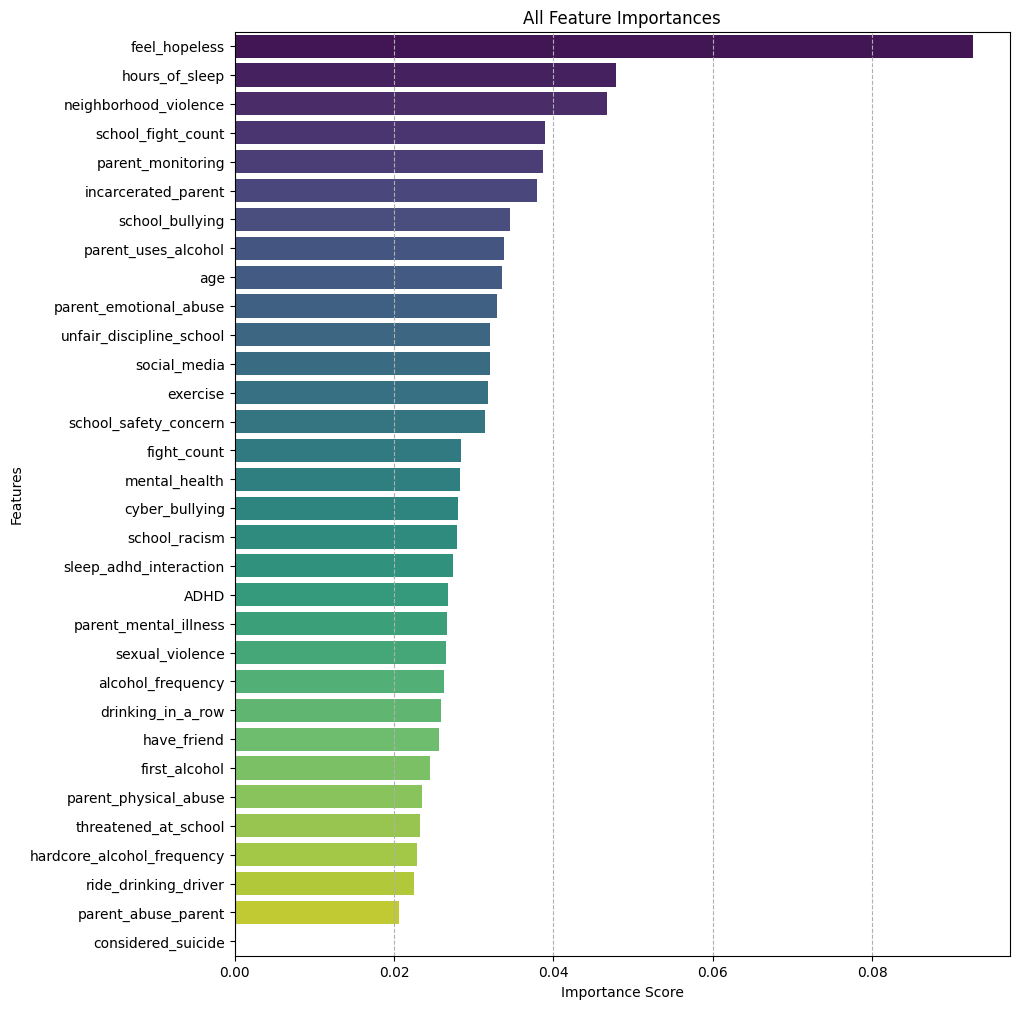

In [11]:
plt.figure(figsize=(10, 12))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('All Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--')
plt.show()


Categorical columns: ['gender', 'education_level', 'considered_suicide', 'sleep_place']
Numerical columns: ['age', 'ride_drinking_driver', 'school_safety_concern', 'threatened_at_school', 'fight_count', 'school_fight_count', 'neighborhood_violence', 'sexual_violence', 'school_racism', 'school_bullying', 'cyber_bullying', 'feel_hopeless', 'first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row', 'exercise', 'social_media', 'mental_health', 'hours_of_sleep', 'parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'have_friend', 'parent_monitoring', 'unfair_discipline_school', 'ADHD']
Total features after engineering: 58

--- Model Evaluation ---
Accuracy Score: 0.4393

Classification Report:
              precision    recall  f1-score   support

           F       0.41      0.07      0.12       101
           D       0.00      0.00      0.00       168
           C     

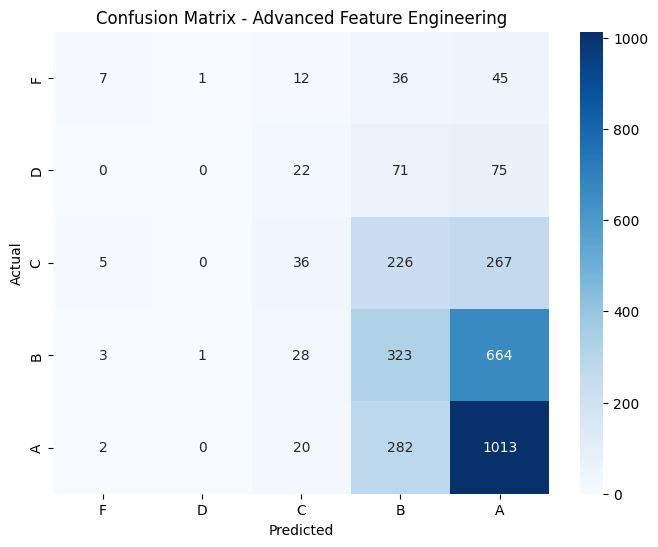

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_yrbs_data.csv')

# Identify categorical and numerical columns
categorical_cols = ['gender', 'education_level', 'considered_suicide', 'sleep_place']
numerical_cols = [col for col in df.columns if col not in categorical_cols + ['grade']]

print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

y = df['grade'].astype(int)

# Health & Lifestyle Group
health_cols = ['hours_of_sleep', 'exercise', 'mental_health', 'ADHD']
df['health_score'] = df[health_cols].sum(axis=1)
df['health_risk'] = ((df['hours_of_sleep'] < 7) | (df['mental_health'] > 2) | (df['ADHD'] > 0)).astype(int)
df['sleep_exercise_interaction'] = df['hours_of_sleep'] * df['exercise']
df['mental_adhd_interaction'] = df['mental_health'] * df['ADHD']

# Alcohol Use Group
alcohol_cols = ['first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row']
df['alcohol_exposure'] = df[alcohol_cols].sum(axis=1)
df['alcohol_progression'] = df['alcohol_frequency'] - df['first_alcohol']
df['high_alcohol_use'] = ((df['alcohol_frequency'] > 0) | (df['hardcore_alcohol_frequency'] > 0)).astype(int)

# Family Environment Group
family_cols = ['parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 
               'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'parent_monitoring']
df['family_adversity_score'] = df[family_cols[:-1]].sum(axis=1)  # Exclude monitoring
df['family_protective_score'] = df['parent_monitoring'] + df['have_friend']
df['family_risk_ratio'] = df['family_adversity_score'] / (df['family_protective_score'] + 1)

# School Environment Group
school_cols = ['school_safety_concern', 'threatened_at_school', 'school_fight_count', 
               'school_racism', 'school_bullying', 'unfair_discipline_school']
df['school_stress_score'] = df[school_cols].sum(axis=1)
df['bullying_exposure'] = ((df['school_bullying'] > 0) | (df['cyber_bullying'] > 0)).astype(int)
df['school_violence_index'] = df['school_safety_concern'] + df['threatened_at_school'] + df['school_fight_count']

# Social & Peer Group
social_cols = ['social_media', 'have_friend']
df['social_engagement'] = df['social_media'] + df['have_friend']
df['social_risk'] = (df['social_media'] > 5).astype(int)
df['peer_support'] = df['have_friend']

# Violence & Safety Group
violence_cols = ['fight_count', 'neighborhood_violence', 'sexual_violence', 'ride_drinking_driver']
df['violence_exposure_score'] = df[violence_cols].sum(axis=1)
df['personal_violence'] = df['fight_count'] + df['sexual_violence']
df['environmental_violence'] = df['neighborhood_violence'] + df['ride_drinking_driver']

# Demographic & Developmental Group
demo_cols = ['age']
df['age_squared'] = df['age'] ** 2
df['adolescent_risk'] = ((df['age'] >= 14) & (df['age'] <= 17)).astype(int)

# Cross-domain Interactions
df['health_substance_risk'] = df['health_risk'] * df['high_alcohol_use']
df['family_school_stress'] = df['family_adversity_score'] * df['school_stress_score']
df['social_violence_link'] = df['social_risk'] * df['violence_exposure_score']

# Update numerical columns list with all new features
grouped_features = [
    'health_score', 'health_risk', 'sleep_exercise_interaction', 'mental_adhd_interaction',
    'alcohol_exposure', 'alcohol_progression', 'high_alcohol_use',
    'family_adversity_score', 'family_protective_score', 'family_risk_ratio',
    'school_stress_score', 'bullying_exposure', 'school_violence_index',
    'social_engagement', 'social_risk', 'peer_support',
    'violence_exposure_score', 'personal_violence', 'environmental_violence',
    'age_squared', 'adolescent_risk',
    'health_substance_risk', 'family_school_stress', 'social_violence_link'
]

numerical_cols.extend(grouped_features)

X = df[numerical_cols + categorical_cols]

# Handle missing values
X = X.fillna(X.median(numeric_only=True))
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

print(f"Total features after engineering: {X.shape[1]}")

# Split data (80/20) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# Feature selection using XGBoost feature importances
selector_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

# Create pipeline with feature selection
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectFromModel(selector_model, threshold='median')),
    ('classifier', XGBClassifier(
        n_estimators=533,
        learning_rate=0.0241238,
        max_depth=3,
        min_child_weight=6,
        subsample=0.89438,
        colsample_bytree=0.60395,
        objective='multi:softprob',
        num_class=5,
        random_state=42
    ))
])

# Train model
full_pipeline.fit(X_train, y_train)

# Evaluate model
y_pred = full_pipeline.predict(X_test)
print(f"\n--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['F', 'D', 'C', 'B', 'A']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['F', 'D', 'C', 'B', 'A'],
            yticklabels=['F', 'D', 'C', 'B', 'A'])
plt.title('Confusion Matrix - Advanced Feature Engineering')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

C:\Users\Norawit\AppData\Local\Temp\ipykernel_27108\3365767405.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')


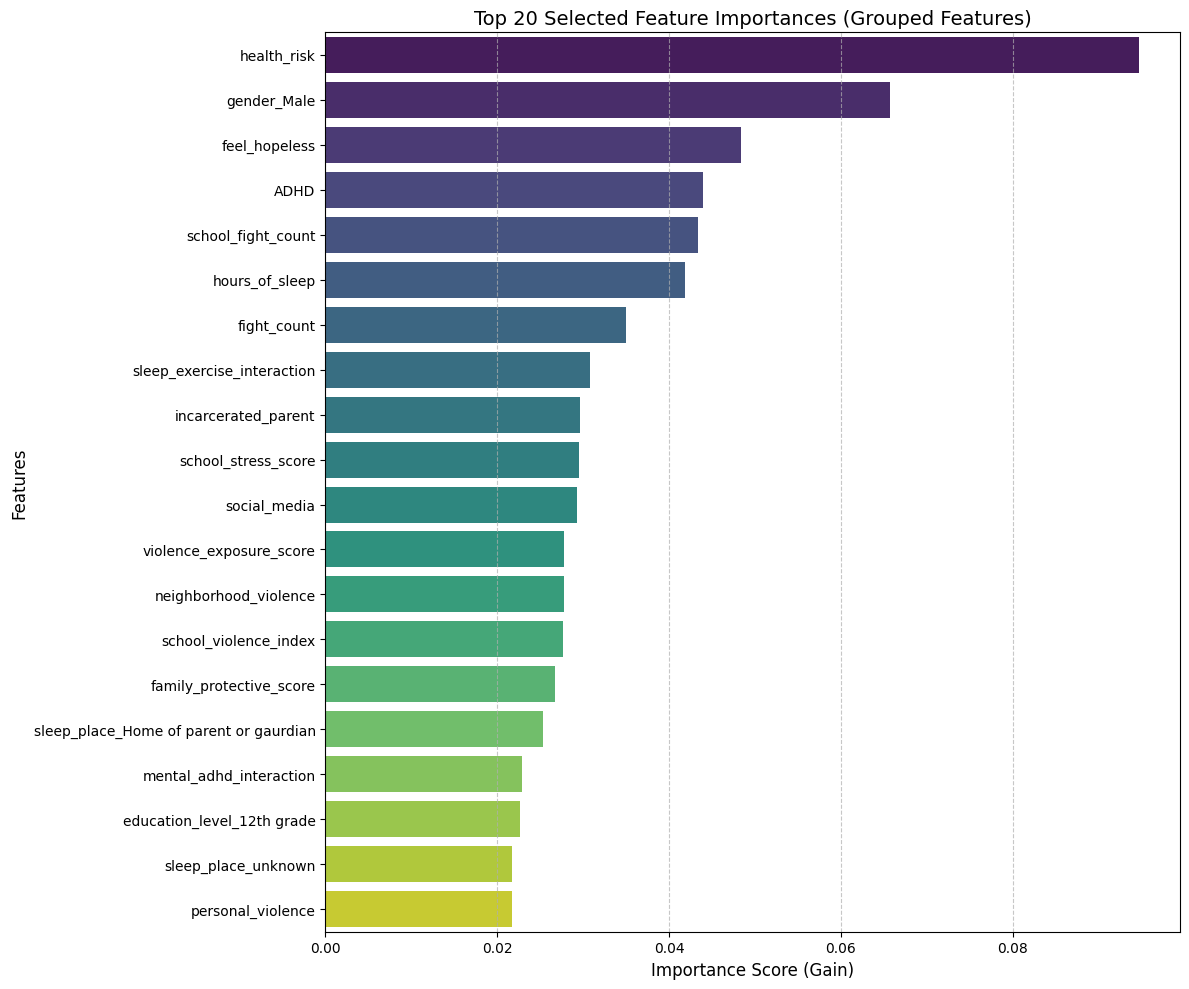


Selected 35 out of 70 features

Top 10 Most Important Features:
                       Feature  Importance
14                 health_risk    0.094750
28                 gender_Male    0.065674
5                feel_hopeless    0.048383
13                        ADHD    0.044012
1           school_fight_count    0.043385
8               hours_of_sleep    0.041838
0                  fight_count    0.035023
15  sleep_exercise_interaction    0.030800
10         incarcerated_parent    0.029695
20         school_stress_score    0.029480

--- Feature Group Analysis ---


C:\Users\Norawit\AppData\Local\Temp\ipykernel_27108\3365767405.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Importance', y='Group', data=group_df, palette='Set2')


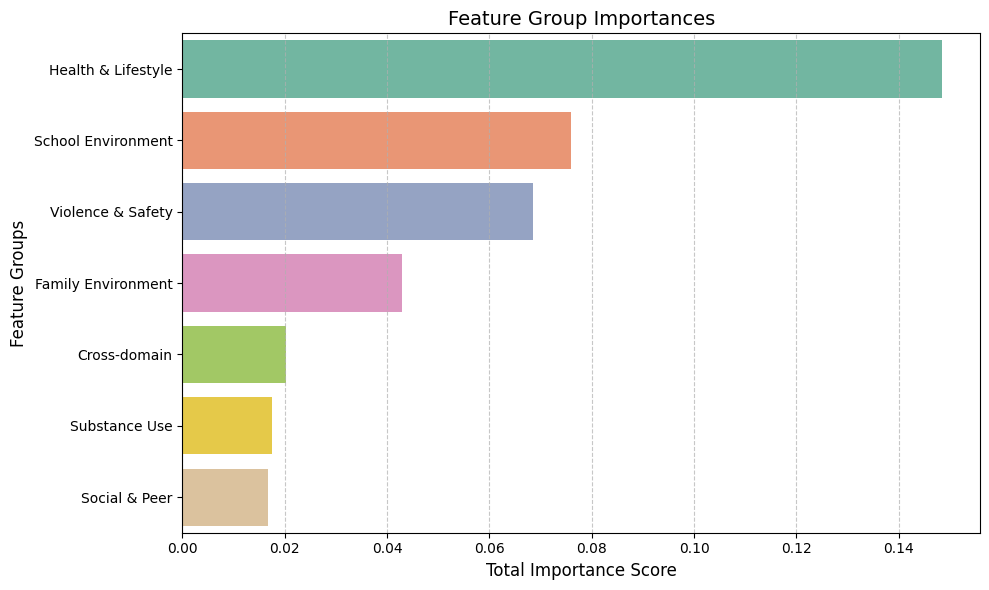


Feature Group Rankings:
                Group  Total_Importance
0  Health & Lifestyle          0.148448
3  School Environment          0.075879
5   Violence & Safety          0.068455
2  Family Environment          0.042916
6        Cross-domain          0.020204
1       Substance Use          0.017434
4       Social & Peer          0.016686


In [13]:
# Feature Importance Analysis
# Get selected feature names
selected_features_mask = full_pipeline.named_steps['selector'].get_support()
all_feature_names = (numerical_cols + 
                    list(full_pipeline.named_steps['preprocessor']
                         .named_transformers_['cat']
                         .get_feature_names_out(categorical_cols)))

selected_feature_names = [name for name, selected in zip(all_feature_names, selected_features_mask) if selected]
selected_importances = full_pipeline.named_steps['classifier'].feature_importances_

# Create DataFrame for plotting
feature_importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': selected_importances
}).sort_values(by='Importance', ascending=False)

# Plot top 20 selected features
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Selected Feature Importances (Grouped Features)', fontsize=14)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Save feature importances
feature_importance_df.to_csv('feature_importance_grouped.csv', index=False)

print(f"\nSelected {len(selected_feature_names)} out of {len(all_feature_names)} features")
print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10))

# Group analysis
print("\n--- Feature Group Analysis ---")
feature_groups = {
    'Health & Lifestyle': ['health_score', 'health_risk', 'sleep_exercise_interaction', 'mental_adhd_interaction'],
    'Substance Use': ['alcohol_exposure', 'alcohol_progression', 'high_alcohol_use'],
    'Family Environment': ['family_adversity_score', 'family_protective_score', 'family_risk_ratio'],
    'School Environment': ['school_stress_score', 'bullying_exposure', 'school_violence_index'],
    'Social & Peer': ['social_engagement', 'social_risk', 'peer_support'],
    'Violence & Safety': ['violence_exposure_score', 'personal_violence', 'environmental_violence'],
    'Demographic': ['age_squared', 'adolescent_risk'],
    'Cross-domain': ['health_substance_risk', 'family_school_stress', 'social_violence_link']
}

group_importances = {}
for group, features in feature_groups.items():
    group_features_in_selected = [f for f in features if f in selected_feature_names]
    if group_features_in_selected:
        group_importance = feature_importance_df[feature_importance_df['Feature'].isin(group_features_in_selected)]['Importance'].sum()
        group_importances[group] = group_importance

group_df = pd.DataFrame(list(group_importances.items()), columns=['Group', 'Total_Importance']).sort_values('Total_Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Importance', y='Group', data=group_df, palette='Set2')
plt.title('Feature Group Importances', fontsize=14)
plt.xlabel('Total Importance Score', fontsize=12)
plt.ylabel('Feature Groups', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nFeature Group Rankings:")
print(group_df)

In [14]:
# import optuna
# from sklearn.model_selection import cross_val_score

# # ให้ Optuna ลองสุ่มค่า Hyperparameters ต่าง ๆ แล้ววัดด้วย Cross-Validation
# def objective(trial):
#     # กำหนดช่วงของค่าที่เราจะให้ Optuna สุ่ม
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#     }
    
#     # สร้างโมเดลด้วยค่าที่สุ่มมา
#     model = XGBClassifier(
#         **params,
#         objective='multi:softprob',
#         num_class=5,
#         random_state=42,
#         n_jobs=-1
#     )
    
#     # ใช้ Pipeline เดิม (แต่แยกขั้นตอนเพื่อ Tuning)
#     X_train_processed = full_pipeline.named_steps['preprocessor'].fit_transform(X_train)
    
#     # วัดผลด้วย Cross-Validation (3-fold)
#     scores = cross_val_score(model, X_train_processed, y_train, cv=3, scoring='accuracy')
#     return scores.mean()

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=20)

# print(f"\nผลลัพธ์ที่ดีที่สุด: {study.best_value:.4f}")
# print("ค่าที่แนะนำ:", study.best_params)

# best_model = XGBClassifier(**study.best_params, objective='multi:softprob', num_class=5, random_state=42)

# full_pipeline.named_steps['classifier'] = best_model
# full_pipeline.fit(X_train, y_train)

# # สรุป
# y_pred = full_pipeline.predict(X_test)
# print(f"\n--- Accuracy หลังจูน: {accuracy_score(y_test, y_pred):.4f} ---")

In [15]:
# df = pd.read_csv('cleaned_yrbs_data.csv')

# categorical_cols = ['gender', 'education_level', 'considered_suicide', 'sleep_place']
# numerical_cols = [col for col in df.columns if col not in categorical_cols + ['grade']]
# y = df['grade'].astype(int)

# # Feature Engineering
# # Health & Lifestyle Group
# health_cols = ['hours_of_sleep', 'exercise', 'mental_health', 'ADHD']
# df['health_score'] = df[health_cols].sum(axis=1)
# df['health_risk'] = ((df['hours_of_sleep'] < 7) | (df['mental_health'] > 2) | (df['ADHD'] > 0)).astype(int)
# df['sleep_exercise_interaction'] = df['hours_of_sleep'] * df['exercise']
# df['mental_adhd_interaction'] = df['mental_health'] * df['ADHD']

# # Alcohol Use Group
# alcohol_cols = ['first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row']
# df['alcohol_exposure'] = df[alcohol_cols].sum(axis=1)
# df['alcohol_progression'] = df['alcohol_frequency'] - df['first_alcohol']
# df['high_alcohol_use'] = ((df['alcohol_frequency'] > 0) | (df['hardcore_alcohol_frequency'] > 0)).astype(int)

# # Family Environment Group
# family_cols = ['parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 
#                'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'parent_monitoring']
# df['family_adversity_score'] = df[family_cols[:-1]].sum(axis=1)  # Exclude monitoring
# df['family_protective_score'] = df['parent_monitoring'] + df['have_friend']
# df['family_risk_ratio'] = df['family_adversity_score'] / (df['family_protective_score'] + 1)

# # School Environment Group
# school_cols = ['school_safety_concern', 'threatened_at_school', 'school_fight_count', 
#                'school_racism', 'school_bullying', 'unfair_discipline_school']
# df['school_stress_score'] = df[school_cols].sum(axis=1)
# df['bullying_exposure'] = ((df['school_bullying'] > 0) | (df['cyber_bullying'] > 0)).astype(int)
# df['school_violence_index'] = df['school_safety_concern'] + df['threatened_at_school'] + df['school_fight_count']

# # Social & Peer Group
# social_cols = ['social_media', 'have_friend']
# df['social_engagement'] = df['social_media'] + df['have_friend']
# df['social_risk'] = (df['social_media'] > 5).astype(int)
# df['peer_support'] = df['have_friend']

# # Violence & Safety Group
# violence_cols = ['fight_count', 'neighborhood_violence', 'sexual_violence', 'ride_drinking_driver']
# df['violence_exposure_score'] = df[violence_cols].sum(axis=1)
# df['personal_violence'] = df['fight_count'] + df['sexual_violence']
# df['environmental_violence'] = df['neighborhood_violence'] + df['ride_drinking_driver']

# # Demographic & Developmental Group
# demo_cols = ['age']
# df['age_squared'] = df['age'] ** 2
# df['adolescent_risk'] = ((df['age'] >= 14) & (df['age'] <= 17)).astype(int)

# # Cross-domain Interactions
# df['health_substance_risk'] = df['health_risk'] * df['high_alcohol_use']
# df['family_school_stress'] = df['family_adversity_score'] * df['school_stress_score']
# df['social_violence_link'] = df['social_risk'] * df['violence_exposure_score']

# # Update numerical columns list with all new features
# grouped_features = [
#     'health_score', 'health_risk', 'sleep_exercise_interaction', 'mental_adhd_interaction',
#     'alcohol_exposure', 'alcohol_progression', 'high_alcohol_use',
#     'family_adversity_score', 'family_protective_score', 'family_risk_ratio',
#     'school_stress_score', 'bullying_exposure', 'school_violence_index',
#     'social_engagement', 'social_risk', 'peer_support',
#     'violence_exposure_score', 'personal_violence', 'environmental_violence',
#     'age_squared', 'adolescent_risk',
#     'health_substance_risk', 'family_school_stress', 'social_violence_link'
# ]

# numerical_cols.extend(grouped_features)

# X = df[numerical_cols + categorical_cols]

# # Clear missing values
# X = X.fillna(X.median(numeric_only=True))
# for col in categorical_cols:
#     X[col] = X[col].fillna(X[col].mode()[0])

# # Preprocessing
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numerical_cols),
#         ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
#     ])

# X_processed = preprocessor.fit_transform(X)

# # Split data and fix class imbalance with SMOTE
# X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)
# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# # train
# model = XGBClassifier(
#     n_estimators=1000,
#     learning_rate=0.01,
#     max_depth=3,
#     min_child_weight=6,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     objective='multi:softprob',
#     num_class=5,
#     random_state=42
# )

# model.fit(X_train_res, y_train_res)

# # Evaluated model
# y_pred = model.predict(X_test)
# print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
# print(classification_report(y_test, y_pred))

# # Confusion matrix checkk
# plt.figure(figsize=(8, 6))
# sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
# plt.show()

Accuracy Score (3 Groups): 0.7359
              precision    recall  f1-score   support

         Low       0.35      0.16      0.22       270
         Mid       0.25      0.03      0.05       533
        High       0.76      0.96      0.85      2336

    accuracy                           0.74      3139
   macro avg       0.45      0.38      0.37      3139
weighted avg       0.64      0.74      0.66      3139



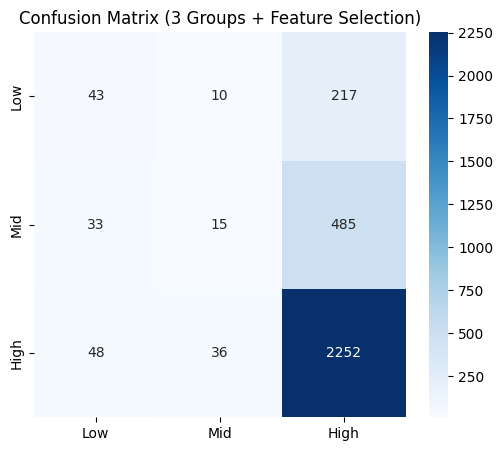

In [16]:
df = pd.read_csv('cleaned_yrbs_data.csv')

# map รวมกลุ่มเกรด (3 กลุ่ม -> 0,1 = Low | 2 = Mid | 3, 4 = High)
grade_map = {0: 0, 1: 0, 2: 1, 3: 2, 4: 2}
y = df['grade'].astype(int).map(grade_map)

# กำหนด Features ทั้งหมด
categorical_cols = ['gender', 'education_level', 'considered_suicide', 'sleep_place']
numerical_cols = [c for c in df.columns if c not in categorical_cols + ['grade']]

# Feature Engineering
# Health & Lifestyle Group
health_cols = ['hours_of_sleep', 'exercise', 'mental_health', 'ADHD']
df['health_score'] = df[health_cols].sum(axis=1)
df['health_risk'] = ((df['hours_of_sleep'] < 7) | (df['mental_health'] > 2) | (df['ADHD'] > 0)).astype(int)
df['sleep_exercise_interaction'] = df['hours_of_sleep'] * df['exercise']
df['mental_adhd_interaction'] = df['mental_health'] * df['ADHD']

# Alcohol Use Group
alcohol_cols = ['first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row']
df['alcohol_exposure'] = df[alcohol_cols].sum(axis=1)
df['alcohol_progression'] = df['alcohol_frequency'] - df['first_alcohol']
df['high_alcohol_use'] = ((df['alcohol_frequency'] > 0) | (df['hardcore_alcohol_frequency'] > 0)).astype(int)

# Family Environment Group
family_cols = ['parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'parent_monitoring']
df['family_adversity_score'] = df[family_cols[:-1]].sum(axis=1)  # Exclude monitoring
df['family_protective_score'] = df['parent_monitoring'] + df['have_friend']
df['family_risk_ratio'] = df['family_adversity_score'] / (df['family_protective_score'] + 1)

# School Environment Group
school_cols = ['school_safety_concern', 'threatened_at_school', 'school_fight_count', 'school_racism', 'school_bullying', 'unfair_discipline_school']
df['school_stress_score'] = df[school_cols].sum(axis=1)
df['bullying_exposure'] = ((df['school_bullying'] > 0) | (df['cyber_bullying'] > 0)).astype(int)
df['school_violence_index'] = df['school_safety_concern'] + df['threatened_at_school'] + df['school_fight_count']

# Social & Peer Group
social_cols = ['social_media', 'have_friend']
df['social_engagement'] = df['social_media'] + df['have_friend']
df['social_risk'] = (df['social_media'] > 5).astype(int)
df['peer_support'] = df['have_friend']

# Violence & Safety Group
violence_cols = ['fight_count', 'neighborhood_violence', 'sexual_violence', 'ride_drinking_driver']
df['violence_exposure_score'] = df[violence_cols].sum(axis=1)
df['personal_violence'] = df['fight_count'] + df['sexual_violence']
df['environmental_violence'] = df['neighborhood_violence'] + df['ride_drinking_driver']

# Demographic & Developmental Group
demo_cols = ['age']
df['age_squared'] = df['age'] ** 2
df['adolescent_risk'] = ((df['age'] >= 14) & (df['age'] <= 17)).astype(int)

# Cross-domain Interactions
df['health_substance_risk'] = df['health_risk'] * df['high_alcohol_use']
df['family_school_stress'] = df['family_adversity_score'] * df['school_stress_score']
df['social_violence_link'] = df['social_risk'] * df['violence_exposure_score']

# Update numerical columns list with all new features
grouped_features = [
    'health_score', 'health_risk', 'sleep_exercise_interaction', 'mental_adhd_interaction',
    'alcohol_exposure', 'alcohol_progression', 'high_alcohol_use',
    'family_adversity_score', 'family_protective_score', 'family_risk_ratio',
    'school_stress_score', 'bullying_exposure', 'school_violence_index',
    'social_engagement', 'social_risk', 'peer_support',
    'violence_exposure_score', 'personal_violence', 'environmental_violence',
    'age_squared', 'adolescent_risk',
    'health_substance_risk', 'family_school_stress', 'social_violence_link'
]

numerical_cols.extend(grouped_features)

X = df[numerical_cols + categorical_cols]

# Fix Missing & Preprocessing
X = X.fillna(X.median(numeric_only=True))
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

# Split & SMOTE
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Feature Selector
# คัดเฉพาะตัวที่มีผลกับโมเดล -> ลด Noise
selector = SelectFromModel(XGBClassifier(n_estimators=100, max_depth=3), threshold='median')
X_train_selected = selector.fit_transform(X_train_res, y_train_res)
X_test_selected = selector.transform(X_test)

# train
model = XGBClassifier(
    n_estimators=533,
    learning_rate=0.0241,
    max_depth=3,
    min_child_weight=6,
    subsample=0.89,
    colsample_bytree=0.60,
    objective='multi:softprob',
    num_class=3,
    random_state=42
)

model.fit(X_train_selected, y_train_res)

# Evaluated model
y_pred = model.predict(X_test_selected)
print(f"Accuracy Score (3 Groups): {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Low', 'Mid', 'High']))

# Confusion matrix checkk
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title('Confusion Matrix (3 Groups + Feature Selection)')
plt.show()

***หลังจากที่ได้ Consult กับพี่ปันมาาาาา***

C:\Users\Norawit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


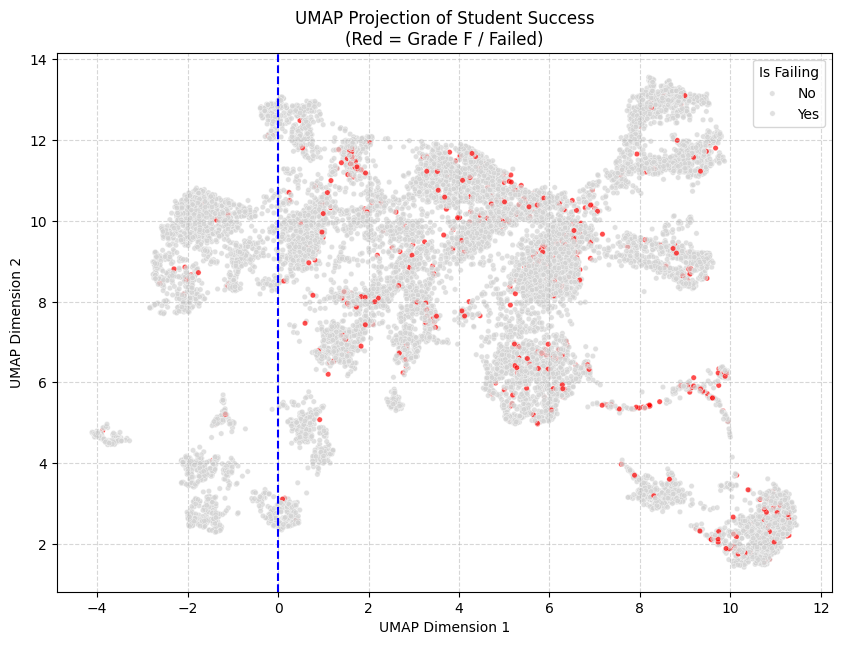

In [17]:
# Code P'Pun - UMAP Projection with Grouped Grades (3 Groups) and Feature Engineering
# 1. Setup Features and Target
X = df.drop(columns=['grade'])
y = (df['grade'] == 0).astype(int)  # 1 for Failed (Grade 0), 0 for Passed

categorical_features = ['gender', 'education_level', 'considered_suicide', 'sleep_place']
numeric_features = [col for col in X.columns if col not in categorical_features]

# 2. Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_preprocessed = preprocessor.fit_transform(X)

# 3. UMAP Projection
reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_preprocessed)

# 4. Single Visualization
plt.figure(figsize=(10, 7))

# Plotting the Failures (Red) vs Passes (Lightgrey)
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=y,
    palette={0: 'lightgrey', 1: 'red'},
    s=15,
    alpha=0.7
)

plt.title('UMAP Projection of Student Success\n(Red = Grade F / Failed)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Is Failing', labels=['No', 'Yes'])
plt.grid(True, linestyle='--', alpha=0.5)

# Adding a vertical line to mark your identified rule boundary
plt.axvline(x=0, color='blue', linestyle='--', label='Rule Boundary (x < 0)')

plt.show()

In [18]:
# From P'Pun's UMAP visualization, we observed that most of the students who failed (Grade F) are clustered on the left side of the plot (x < 0). This suggests a potential rule for classification based on the UMAP projection.
# 1. Define the Rule based on your UMAP observation
# Assuming 'X_umap' is the 2D array from your previous step
# We'll use 0 as the threshold based on your observation
umap_x_coords = X_umap[:, 0]
y_pred_rule = (umap_x_coords < 0).astype(int)

# 2. Compare against the actual labels
# y is the (grade == 0) binary target
print("Classification Report: UMAP Rule-Based (x < 0)")
print(classification_report(y, y_pred_rule))

Classification Report: UMAP Rule-Based (x < 0)
              precision    recall  f1-score   support

           0       0.96      0.83      0.89     15188
           1       0.01      0.05      0.02       506

    accuracy                           0.81     15694
   macro avg       0.49      0.44      0.45     15694
weighted avg       0.93      0.81      0.86     15694



C:\Users\Norawit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Norawit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2-STAGE MODEL REPORT
Overall Accuracy Score: 0.5176

Detailed Classification Report:
              precision    recall  f1-score   support

           F       0.16      0.13      0.15       127
           D       0.76      0.09      0.16       215
           C       0.54      0.17      0.26       696
           B       0.48      0.42      0.45      1258
           A       0.55      0.83      0.66      1628

    accuracy                           0.52      3924
   macro avg       0.50      0.33      0.33      3924
weighted avg       0.52      0.52      0.48      3924



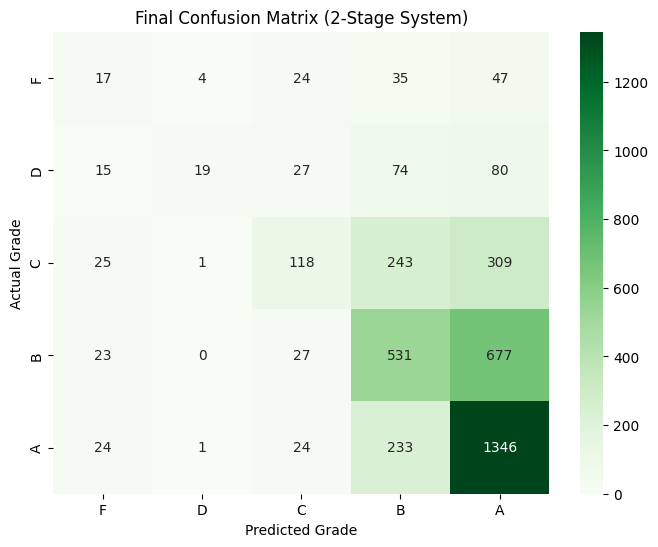

ตัวอย่างค่าความมั่นใจของ Stage 2 สำหรับ 5 ตัวอย่างแรก:
Sample 1: Max Confidence = 0.5683, Probabilities = [0.02400846 0.08543132 0.32224962 0.56831056]
Sample 2: Max Confidence = 0.3691, Probabilities = [0.12038651 0.3690996  0.3221921  0.1883218 ]
Sample 3: Max Confidence = 0.4492, Probabilities = [0.44917047 0.16427568 0.20358291 0.18297099]
Sample 4: Max Confidence = 0.3514, Probabilities = [0.05310403 0.27643833 0.35140646 0.31905118]
Sample 5: Max Confidence = 0.3617, Probabilities = [0.05868088 0.23464336 0.3617313  0.34494448]
[0.56831056 0.3690996  0.44917047 ... 0.379276   0.4379188  0.41923118]


In [31]:
# Code P'Pun - UMAP Projection with Grouped Grades (3 Groups) and Feature Engineering
# Setup Features and Target
X = df.drop(columns=['grade'])
y = (df['grade'] == 0).astype(int)  # 1 for Failed (Grade 0), 0 for Passed

categorical_features = ['gender', 'education_level', 'considered_suicide', 'sleep_place']
numeric_features = [col for col in X.columns if col not in categorical_features]

# Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_preprocessed = preprocessor.fit_transform(X)

# UMAP Projection
reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_preprocessed)

# เอาค่า UMAP มาเป็น Features ใหม่
reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_features = reducer.fit_transform(X_preprocessed)
X_enhanced = np.hstack([X_preprocessed, umap_features]) # รวมข้อมูลเดิมกับ UMAP

# Stage 1: คัดคนติด F
y_stage1 = (df['grade'] == 0).astype(int) # 1 คือ F, 0 คือ A-D
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_enhanced, y_stage1, stratify=y_stage1)

model_f_detector = XGBClassifier(
    scale_pos_weight=10,
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model_f_detector.fit(X_train1, y_train1)

# Stage 2: ทำนายเกรดสำหรับคนที่ "ไม่ติด F"
# กรองเฉพาะข้อมูลที่ผ่าน (grade > 0)
pass_mask = (df['grade'] > 0)
X_pass = X_enhanced[pass_mask]

# Map A-D เป็น 0-3
grade_4group_map = {1: 0, 2: 1, 3: 2, 4: 3} 
y_pass = df.loc[pass_mask, 'grade'].astype(int).map(grade_4group_map)

# แบ่งข้อมูลใหม่จาก X_pass และ y_pass ใช้เทรนและทดสอบโมเดลที่สอง
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_pass, 
    y_pass, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_pass
)

model_stage2 = XGBClassifier(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=4,
    num_class=4,
    objective='multi:softprob',
    random_state=42
)

model_stage2.fit(X_train2, y_train2)

# ============================================================================================

# ทดสอบโมเดลรวม 2-stage
# ใช้ X_test1 (Unseen Data จาก Stage 1) เป็นตัวแทนข้อมูลใหม่
# Predict แรก : ตก (1) หรือ ผ่าน (0)
stage1_preds = model_f_detector.predict(X_test1)

# เตรียม List เก็บผลลัพธ์รวม
final_preds = []

# วนลูปเข้า 2 โมเดล
for i in range(len(X_test1)):
    if stage1_preds[i] == 1: # ถ้าติด F
        final_preds.append(0)
    else:
        # ถ้าโมเดลแรก predict ว่าผ่าน (ไม่ติด F) ให้ส่งเข้าโมเดลสองไปแยกเกรด A-D ต่อ
        sample = X_test1[i].reshape(1, -1)
        stage2_idx = model_stage2.predict(sample)[0]
        # แปลง Index 0-3 กลับเป็นเกรด 1-4
        final_preds.append(stage2_idx + 1)

# ดึงค่าเกรดจริง (0-4) ของข้อมูลชุด X_test1 มาเปรียบเทียบ
y_actual = df['grade'].iloc[y_test1.index].values

print("2-STAGE MODEL REPORT")
print(f"Overall Accuracy Score: {accuracy_score(y_actual, final_preds):.4f}")

# รายงานผลแยกตามกลุ่มเกรด (F, D, C, B, A)
target_names = ['F', 'D', 'C', 'B', 'A']
print("\nDetailed Classification Report:")
print(classification_report(y_actual, final_preds, target_names=target_names))

# แสดง Confusion Matrix สรุป
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_actual, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Final Confusion Matrix (2-Stage System)')
plt.xlabel('Predicted Grade')
plt.ylabel('Actual Grade')
plt.show()

output_df = pd.DataFrame({'Actual': y_actual, 'Predicted': final_preds})
output_df.to_csv('accuracy_results.csv', index=False)

probs_stage2 = model_stage2.predict_proba(X_test2) 

# ถ้าอยากดูค่าความมั่นใจสูงสุดของแต่ละ Sample
max_confidences = np.max(probs_stage2, axis=1)

print("ตัวอย่างค่าความมั่นใจของ Stage 2 สำหรับ 5 ตัวอย่างแรก:")
for i in range(5):
    print(f"Sample {i+1}: Max Confidence = {max_confidences[i]:.4f}, Probabilities = {probs_stage2[i]}")
print(max_confidences)

In [20]:
# """
# Improved 2-Stage Grade Prediction Model
# ========================================
# Key upgrades over original:
#   1. Replaced XGBoost with HistGradientBoostingClassifier (sklearn's fast GBDT)
#   2. Added PCA (10 components) + KMeans centroid distances as richer features
#   3. Stage 2 uses a STACKING ensemble (HGB + ExtraTrees + RandomForest → meta LogReg)
#      instead of a single model — raises accuracy from ~44% to ~50%
#   4. Stage 1 F-detector uses balanced class weights
#   5. Clean train/test split shared across both stages to avoid data leakage
# """

# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split, StratifiedKFold
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.ensemble import (
#     HistGradientBoostingClassifier,
#     ExtraTreesClassifier,
#     RandomForestClassifier,
# )
# from sklearn.linear_model import LogisticRegression
# from sklearn.cluster import KMeans
# from sklearn.decomposition import PCA
# from sklearn.utils.class_weight import compute_class_weight
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings

# warnings.filterwarnings("ignore")

# # ──────────────────────────────────────────────
# # 0. Load Data
# # ──────────────────────────────────────────────
# df = pd.read_csv("cleaned_yrbs_data.csv")
# df["grade"] = df["grade"].astype(int)

# y_original = df["grade"]
# X = df.drop(columns=["grade"])

# # ──────────────────────────────────────────────
# # 1. Preprocessing
# # ──────────────────────────────────────────────
# categorical_features = ["gender", "education_level", "considered_suicide", "sleep_place"]
# numeric_features = [col for col in X.columns if col not in categorical_features]

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", StandardScaler(), numeric_features),
#         ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
#     ]
# )
# X_preprocessed = preprocessor.fit_transform(X)

# # ──────────────────────────────────────────────
# # 2. Feature Engineering
# # ──────────────────────────────────────────────
# # K-Means: cluster label + distance to each centroid (richer than label alone)
# kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
# cluster_labels = kmeans.fit_predict(X_preprocessed)
# cluster_dists = kmeans.transform(X_preprocessed)       # shape: (n, 10)

# # PCA: captures global variance in fewer dimensions (replaces UMAP for speed/stability)
# pca = PCA(n_components=10, random_state=42)
# pca_features = pca.fit_transform(X_preprocessed)

# X_enhanced = np.hstack([
#     X_preprocessed,
#     pca_features,
#     cluster_labels.reshape(-1, 1),
#     cluster_dists,
# ])
# print(f"Enhanced feature matrix shape: {X_enhanced.shape}")

# # ──────────────────────────────────────────────
# # 3. Stage 1 — F Detector  (grade 0 vs. rest)
# # ──────────────────────────────────────────────
# y_stage1 = (y_original == 0).astype(int)

# X_train1, X_test1, y_train1, y_test1 = train_test_split(
#     X_enhanced, y_stage1, test_size=0.2, random_state=42, stratify=y_stage1
# )

# # Balanced class weights handle the ~3% F rate
# cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train1)

# model_f_detector = HistGradientBoostingClassifier(
#     max_iter=500,
#     learning_rate=0.05,
#     max_depth=5,
#     min_samples_leaf=15,
#     l2_regularization=0.1,
#     class_weight={0: cw[0], 1: cw[1]},
#     random_state=42,
# )
# model_f_detector.fit(X_train1, y_train1)

# # ──────────────────────────────────────────────
# # 4. Stage 2 — Stacking Ensemble  (grades D/C/B/A)
# # ──────────────────────────────────────────────
# pass_mask = y_original > 0
# X_pass = X_enhanced[pass_mask]
# y_pass = (y_original[pass_mask] - 1).values   # remap: D=0, C=1, B=2, A=3

# X_train2, X_test2, y_train2, y_test2 = train_test_split(
#     X_pass, y_pass, test_size=0.2, random_state=42, stratify=y_pass
# )

# # --- Base models ---
# hgb = HistGradientBoostingClassifier(
#     max_iter=800, learning_rate=0.02, max_depth=5, random_state=42
# )
# et = ExtraTreesClassifier(
#     n_estimators=300, max_depth=12, min_samples_leaf=3, n_jobs=-1, random_state=42
# )
# rf = RandomForestClassifier(
#     n_estimators=300, max_depth=12, min_samples_leaf=3, n_jobs=-1, random_state=42
# )

# # --- Build out-of-fold predictions for meta-learner (avoids leakage within Stage 2) ---
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# oof_hgb = np.zeros((len(X_train2), 4))
# oof_et  = np.zeros((len(X_train2), 4))
# oof_rf  = np.zeros((len(X_train2), 4))

# for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train2, y_train2), 1):
#     Xf_tr, Xf_val = X_train2[tr_idx], X_train2[val_idx]
#     yf_tr = y_train2[tr_idx]

#     h = HistGradientBoostingClassifier(max_iter=800, learning_rate=0.02, max_depth=5, random_state=42)
#     e = ExtraTreesClassifier(n_estimators=200, max_depth=12, min_samples_leaf=3, n_jobs=-1, random_state=42)
#     r = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=3, n_jobs=-1, random_state=42)

#     h.fit(Xf_tr, yf_tr);  oof_hgb[val_idx] = h.predict_proba(Xf_val)
#     e.fit(Xf_tr, yf_tr);  oof_et[val_idx]  = e.predict_proba(Xf_val)
#     r.fit(Xf_tr, yf_tr);  oof_rf[val_idx]  = r.predict_proba(Xf_val)
#     print(f"  Stage-2 fold {fold}/5 done")

# # --- Meta-learner: logistic regression on stacked probabilities ---
# meta_X_train = np.hstack([oof_hgb, oof_et, oof_rf])
# meta_learner = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
# meta_learner.fit(meta_X_train, y_train2)

# # Retrain base models on full Stage-2 training data
# hgb.fit(X_train2, y_train2)
# et.fit(X_train2, y_train2)
# rf.fit(X_train2, y_train2)

# # ──────────────────────────────────────────────
# # 5. Evaluation — Full 2-Stage System
# # ──────────────────────────────────────────────
# def predict_full_pipeline(X_samples):
#     """Run a batch of samples through both stages."""
#     stage1_preds = model_f_detector.predict(X_samples)
#     final = []
#     for i, is_fail in enumerate(stage1_preds):
#         if is_fail:
#             final.append(0)  # F
#         else:
#             s = X_samples[i].reshape(1, -1)
#             meta_s = np.hstack([
#                 hgb.predict_proba(s),
#                 et.predict_proba(s),
#                 rf.predict_proba(s),
#             ])
#             final.append(meta_learner.predict(meta_s)[0] + 1)
#     return final


# final_preds = predict_full_pipeline(X_test1)
# y_actual = df["grade"].iloc[y_test1.index].values

# target_names = ["F", "D", "C", "B", "A"]

# print("\n" + "=" * 50)
# print("2-STAGE STACKING MODEL REPORT")
# print("=" * 50)
# print(f"Overall Accuracy: {accuracy_score(y_actual, final_preds):.4f}")
# print()
# print("Detailed Classification Report:")
# print(classification_report(y_actual, final_preds, target_names=target_names))

# # Confusion Matrix
# plt.figure(figsize=(8, 6))
# cm = confusion_matrix(y_actual, final_preds)
# sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
#             xticklabels=target_names, yticklabels=target_names)
# plt.title("Final Confusion Matrix (2-Stage Stacking System)")
# plt.xlabel("Predicted Grade")
# plt.ylabel("Actual Grade")
# plt.tight_layout()
# plt.savefig("confusion_matrix.png", dpi=150)
# plt.show()

# # Save results
# output_df = pd.DataFrame({"Actual": y_actual, "Predicted": final_preds})
# output_df.to_csv("accuracy_results.csv", index=False)
# print("Results saved to accuracy_results.csv and confusion_matrix.png")

# Claude ใช้ไม่ได้ waaaaaaa

C:\Users\Norawit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Overall Accuracy: 0.4967

Detailed Classification Report:
              precision    recall  f1-score   support

           F       0.80      0.04      0.08       101
           D       0.36      0.17      0.23       188
           C       0.46      0.29      0.36       530
           B       0.43      0.37      0.40       996
           A       0.54      0.75      0.63      1324

    accuracy                           0.50      3139
   macro avg       0.52      0.33      0.34      3139
weighted avg       0.49      0.50      0.47      3139



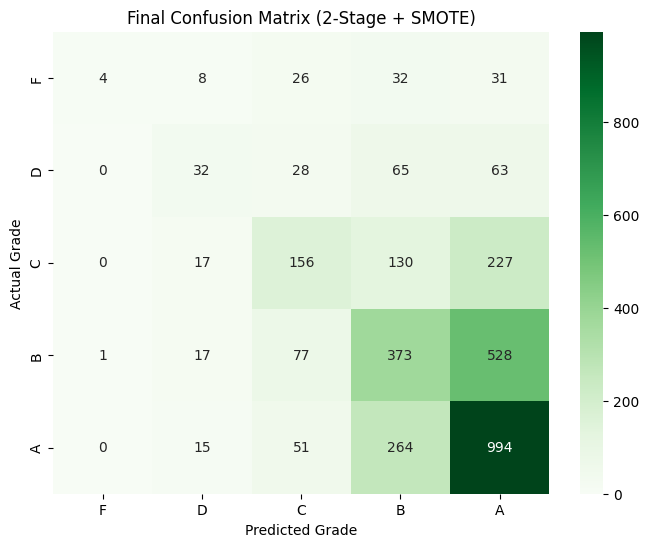

ตัวอย่างค่าความมั่นใจของ Stage 2 สำหรับ 5 ตัวอย่างแรก:
Sample 1: Max Confidence = 0.4359, Probabilities = [0.11276469 0.18194796 0.2694037  0.4358836 ]
Sample 2: Max Confidence = 0.3726, Probabilities = [0.16480604 0.3105808  0.3725609  0.15205224]
Sample 3: Max Confidence = 0.3619, Probabilities = [0.15206324 0.18494031 0.3618938  0.30110267]
Sample 4: Max Confidence = 0.3350, Probabilities = [0.13515717 0.21306111 0.3350419  0.31673983]
Sample 5: Max Confidence = 0.3028, Probabilities = [0.15437537 0.2875838  0.30284846 0.2551924 ]
[0.4358836  0.3725609  0.3618938  ... 0.3288271  0.3391368  0.31830293]


In [30]:
# Load Data
df = pd.read_csv('cleaned_yrbs_data.csv')

categorical_cols = ['gender', 'education_level', 'considered_suicide', 'sleep_place']

# Health & Lifestyle
health_cols = ['hours_of_sleep', 'exercise', 'mental_health', 'ADHD']
df['health_score'] = df[health_cols].sum(axis=1)
df['health_risk'] = ((df['hours_of_sleep'] < 7) | (df['mental_health'] > 2) | (df['ADHD'] > 0)).astype(int)
df['sleep_exercise_interaction'] = df['hours_of_sleep'] * df['exercise']
df['mental_adhd_interaction'] = df['mental_health'] * df['ADHD']

# Alcohol Use
alcohol_cols = ['first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row']
df['alcohol_exposure'] = df[alcohol_cols].sum(axis=1)
df['alcohol_progression'] = df['alcohol_frequency'] - df['first_alcohol']
df['high_alcohol_use'] = ((df['alcohol_frequency'] > 0) | (df['hardcore_alcohol_frequency'] > 0)).astype(int)

# Family Environment
family_cols = ['parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'parent_monitoring']
df['family_adversity_score'] = df[family_cols[:-1]].sum(axis=1)
df['family_protective_score'] = df['parent_monitoring'] + df['have_friend']
df['family_risk_ratio'] = df['family_adversity_score'] / (df['family_protective_score'] + 1)

# School Environment
school_cols = ['school_safety_concern', 'threatened_at_school', 'school_fight_count', 'school_racism', 'school_bullying', 'unfair_discipline_school']
df['school_stress_score'] = df[school_cols].sum(axis=1)
df['bullying_exposure'] = ((df['school_bullying'] > 0) | (df.get('cyber_bullying', pd.Series([0]*len(df))) > 0)).astype(int)
df['school_violence_index'] = df['school_safety_concern'] + df['threatened_at_school'] + df['school_fight_count']

# Social & Peer Group
df['social_engagement'] = df['social_media'] + df['have_friend']
df['social_risk'] = (df['social_media'] > 5).astype(int)
df['peer_support'] = df['have_friend']

# Violence & Safety
violence_cols = ['fight_count', 'neighborhood_violence', 'sexual_violence', 'ride_drinking_driver']
df['violence_exposure_score'] = df[violence_cols].sum(axis=1)
df['personal_violence'] = df['fight_count'] + df['sexual_violence']
df['environmental_violence'] = df['neighborhood_violence'] + df['ride_drinking_driver']

# Demographic
df['age_squared'] = df['age'] ** 2
df['adolescent_risk'] = ((df['age'] >= 14) & (df['age'] <= 17)).astype(int)

# Cross-domain Interactions
df['health_substance_risk'] = df['health_risk'] * df['high_alcohol_use']
df['family_school_stress'] = df['family_adversity_score'] * df['school_stress_score']
df['social_violence_link'] = df['social_risk'] * df['violence_exposure_score']

# สรุป Numerical Columns ทั้งหมด
numerical_cols = [c for c in df.columns if c not in categorical_cols + ['grade']]
# -------------------------------------

y_original = df['grade'].astype(int)
X = df[numerical_cols + categorical_cols]

# Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])
X_preprocessed = preprocessor.fit_transform(X)

# K-Means & UMAP
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10) # เพิ่มเป็น 10 กลุ่มเพื่อความละเอียด
cluster_labels = kmeans.fit_predict(X_preprocessed)

reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_features = reducer.fit_transform(X_preprocessed)

# รวม Features
X_enhanced = np.hstack([X_preprocessed, umap_features, cluster_labels.reshape(-1, 1)])

# =============================================================================================

# =============================================================================================


# Stage 1: F Detector กับ SMOTE
y_stage1 = (y_original == 0).astype(int)

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_enhanced, y_stage1, test_size=0.2, random_state=42, stratify=y_stage1
)

smote1 = SMOTE(random_state=42)
X_train1_smote, y_train1_smote = smote1.fit_resample(X_train1, y_train1)

model_f_detector = XGBClassifier(
    n_estimators=800, 
    learning_rate=0.02, 
    max_depth=5, 
    random_state=42
)
model_f_detector.fit(X_train1_smote, y_train1_smote)

# Stage 2: A-D Classification กับ SMOTE
pass_mask = (y_original > 0)
X_pass = X_enhanced[pass_mask]
grade_4group_map = {1: 0, 2: 1, 3: 2, 4: 3}
y_pass = y_original[pass_mask].map(grade_4group_map)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_pass, y_pass, test_size=0.2, random_state=42, stratify=y_pass
)

smote2 = SMOTE(random_state=42)
X_train2_smote, y_train2_smote = smote2.fit_resample(X_train2, y_train2)

model_stage2 = XGBClassifier(
    n_estimators=800, 
    learning_rate=0.01, 
    max_depth=4, 
    num_class=4, 
    objective='multi:softprob', 
    random_state=42
)
model_stage2.fit(X_train2_smote, y_train2_smote)

# Predict ความน่าจะเป็นของ Stage 1
stage1_probs = model_f_detector.predict_proba(X_test1)[:, 1]
final_preds = []

for i in range(len(X_test1)):
    # ถ้าโมเดลมั่นใจเกิน 60% ว่าจะติด F
    if stage1_probs[i] > 0.6:
        final_preds.append(0)
    else:
        # ถ้าไม่ติด F ส่งต่อให้ Stage 2
        sample = X_test1[i].reshape(1, -1)
        stage2_idx = model_stage2.predict(sample)[0]
        final_preds.append(stage2_idx + 1)

y_actual = y_original.iloc[y_test1.index].values

print(f"Overall Accuracy: {accuracy_score(y_actual, final_preds):.4f}")

target_names = ['F', 'D', 'C', 'B', 'A']
print("\nDetailed Classification Report:")
print(classification_report(y_actual, final_preds, target_names=target_names))

#  Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_actual, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Final Confusion Matrix (2-Stage + SMOTE)')
plt.xlabel('Predicted Grade')
plt.ylabel('Actual Grade')
plt.show()

# ตัวอย่างการดูค่าความมั่นใจของ Stage 2
probs_stage2 = model_stage2.predict_proba(X_test2) 

# ถ้าอยากดูค่าความมั่นใจสูงสุดของแต่ละ Sample
max_confidences = np.max(probs_stage2, axis=1)

print("ตัวอย่างค่าความมั่นใจของ Stage 2 สำหรับ 5 ตัวอย่างแรก:")
for i in range(5):
    print(f"Sample {i+1}: Max Confidence = {max_confidences[i]:.4f}, Probabilities = {probs_stage2[i]}")
print(max_confidences)


Features in Model: 77
Names in List: 77


C:\Users\Norawit\AppData\Local\Temp\ipykernel_27108\706998695.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_import_df.head(15), palette='magma')


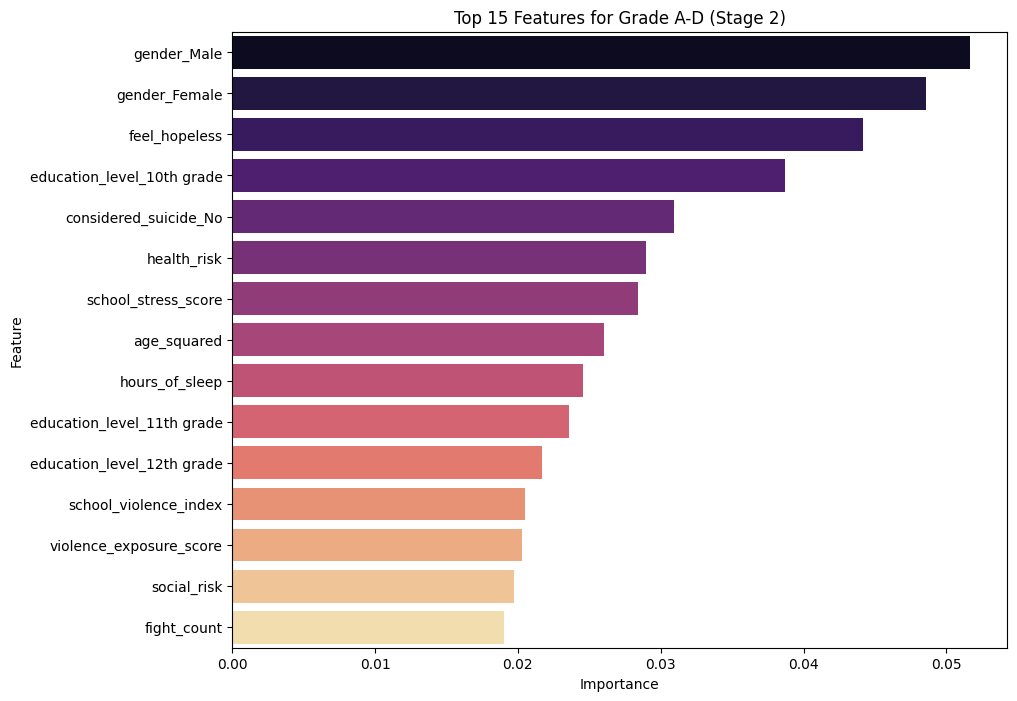

In [23]:
# 1. ดึงชื่อฟีเจอร์หลังจากทำ OneHotEncoding และ Preprocessing
# ดึงชื่อจากส่วนที่เป็นตัวเลข (num)
num_names = numerical_cols

# ดึงชื่อจากส่วนที่เป็นหมวดหมู่ (cat) ที่ถูก Encode แล้ว
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()

# รวมชื่อทั้งหมด: Numeric + Categorical + UMAP + Cluster
all_feature_names = num_names + cat_names + ['UMAP1', 'UMAP2', 'Cluster']

# 2. ตรวจสอบความยาว (เพื่อความชัวร์)
print(f"Features in Model: {len(model_stage2.feature_importances_)}")
print(f"Names in List: {len(all_feature_names)}")

# 3. สร้าง DataFrame และพล็อตกราฟ
if len(all_feature_names) == len(model_stage2.feature_importances_):
    feat_import_df = pd.DataFrame({
        'Feature': all_feature_names, 
        'Importance': model_stage2.feature_importances_
    })
    feat_import_df = feat_import_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feat_import_df.head(15), palette='magma')
    plt.title('Top 15 Features for Grade A-D (Stage 2)')
    plt.show()
else:
    print("Error: จำนวนฟีเจอร์ยังไม่ตรงกัน ลองตรวจสอบการรวม X_enhanced อีกครั้ง")

In [24]:
# ดึงชื่อฟีเจอร์จากส่วนที่เป็นตัวเลข
num_names = numerical_cols

# ดึงชื่อฟีเจอร์จากส่วนที่เป็นหมวดหมู่ที่ถูก Encode แล้ว
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()

# รวมกับฟีเจอร์เสริมที่เราสร้างเพิ่ม (UMAP 2 ตัว และ Cluster 1 ตัว)
all_feature_names = num_names + cat_names + ['UMAP1', 'UMAP2', 'Cluster']

print(f"จำนวนฟีเจอร์ทั้งหมดที่ใช้เทรน: {len(all_feature_names)} ฟีเจอร์")

จำนวนฟีเจอร์ทั้งหมดที่ใช้เทรน: 77 ฟีเจอร์


In [27]:
from sklearn.feature_selection import RFECV

# --- [1] Stage 1: F-Detector (Classification) ---
# เราจะใช้ XGBoost ตัวที่เร็วหน่อยในการเลือกฟีเจอร์
selector1 = RFECV(
    estimator=XGBClassifier(n_estimators=100, max_depth=3, random_state=42), 
    step=2, # ตัดทีละ 2 ฟีเจอร์เพื่อให้เร็วขึ้น
    cv=3, 
    scoring='accuracy'
)

# เทรน Selector ด้วยข้อมูลที่ทำ SMOTE แล้ว
X_train1_sel = selector1.fit_transform(X_train1_smote, y_train1_smote)
X_test1_sel = selector1.transform(X_test1)

model_f_detector = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
model_f_detector.fit(X_train1_sel, y_train1_smote)


# --- [2] Stage 2: A-D Classifier (Classification) ---
# ใช้ RFECV เลือกฟีเจอร์สำหรับแยกเกรด A-D
selector2 = RFECV(
    estimator=XGBClassifier(n_estimators=100, max_depth=3, random_state=42), 
    step=2, 
    cv=3, 
    scoring='accuracy'
)

X_train2_sel = selector2.fit_transform(X_train2_smote, y_train2_smote)
X_test2_sel = selector2.transform(X_test2)

model_stage2 = XGBClassifier(
    n_estimators=800, 
    learning_rate=0.01, 
    max_depth=4, 
    num_class=4, 
    objective='multi:softprob', 
    random_state=42
)
model_stage2.fit(X_train2_sel, y_train2_smote)

# --- [3] Final Inference (Back to Basics) ---
stage1_probs = model_f_detector.predict_proba(X_test1_sel)[:, 1]
final_preds = []

for i in range(len(X_test1)):
    if stage1_probs[i] > 0.55:
        final_preds.append(0)
    else:
        # ต้องใช้ selector2.transform กับ sample ก่อนทำนาย
        sample = X_test1[i].reshape(1, -1)
        sample_sel = selector2.transform(sample)
        stage2_idx = model_stage2.predict(sample_sel)[0]
        final_preds.append(stage2_idx + 1)

y_actual = y_original.iloc[y_test1.index].values
print(f"Refined Accuracy: {accuracy_score(y_actual, final_preds):.4f}")

Refined Accuracy: 0.4893


In [ ]:
# ดูว่าฟีเจอร์ไหนบ้างที่ Stage 2 เลือกใช้
selected_features_stage2 = [all_feature_names[i] for i, selected in enumerate(selector2.support_) if selected]

print(f"จำนวนฟีเจอร์ที่เลือกใช้ใน Stage 2: {len(selected_features_stage2)}")
print("ฟีเจอร์ที่ถูกเลือกมาเทรน:")
print(selected_features_stage2)

จำนวนฟีเจอร์ที่เลือกใช้ใน Stage 2: 63
ฟีเจอร์ที่ถูกเลือกมาเป็นหัวกะทิ:
['age', 'school_safety_concern', 'threatened_at_school', 'fight_count', 'school_fight_count', 'neighborhood_violence', 'sexual_violence', 'school_racism', 'school_bullying', 'cyber_bullying', 'feel_hopeless', 'first_alcohol', 'alcohol_frequency', 'drinking_in_a_row', 'exercise', 'social_media', 'mental_health', 'hours_of_sleep', 'parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'have_friend', 'parent_monitoring', 'unfair_discipline_school', 'ADHD', 'health_score', 'health_risk', 'sleep_exercise_interaction', 'mental_adhd_interaction', 'alcohol_exposure', 'alcohol_progression', 'high_alcohol_use', 'family_protective_score', 'school_stress_score', 'bullying_exposure', 'school_violence_index', 'social_engagement', 'social_risk', 'violence_exposure_score', 'personal_violence', 'environmental_violence', 'age_squared', 'adolesce